In [ ]:
import drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/titanic_h.csv")     #اینپورت کردن دیتاست

In [ ]:
# نمایش نام ستون‌ها
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')


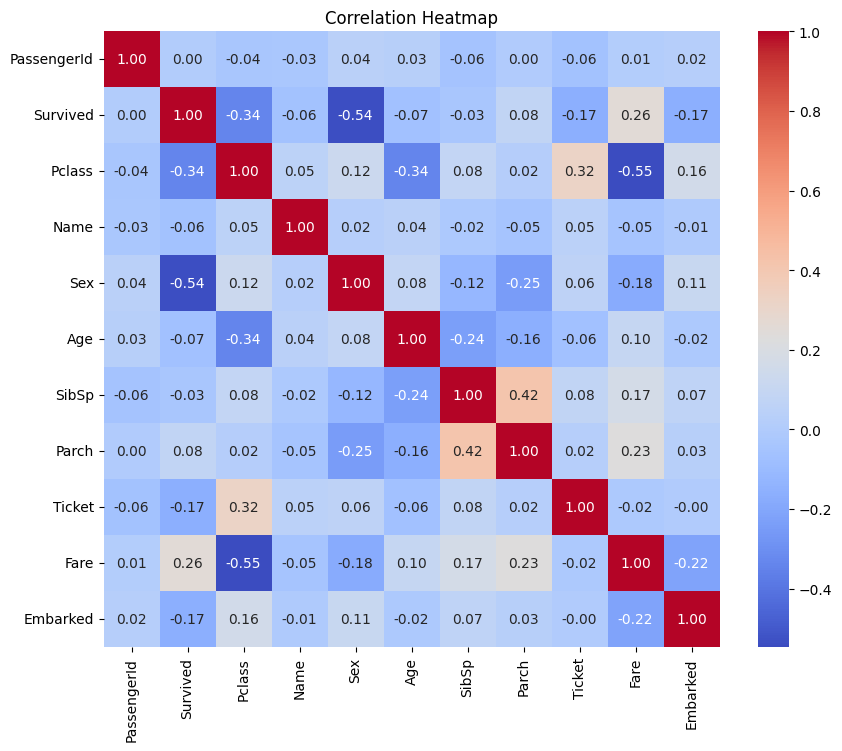

In [ ]:
# محاسبه همبستگی
correlation_matrix = df.corr()

# رسم نمودار حرارتی
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Heatmap')
plt.show()

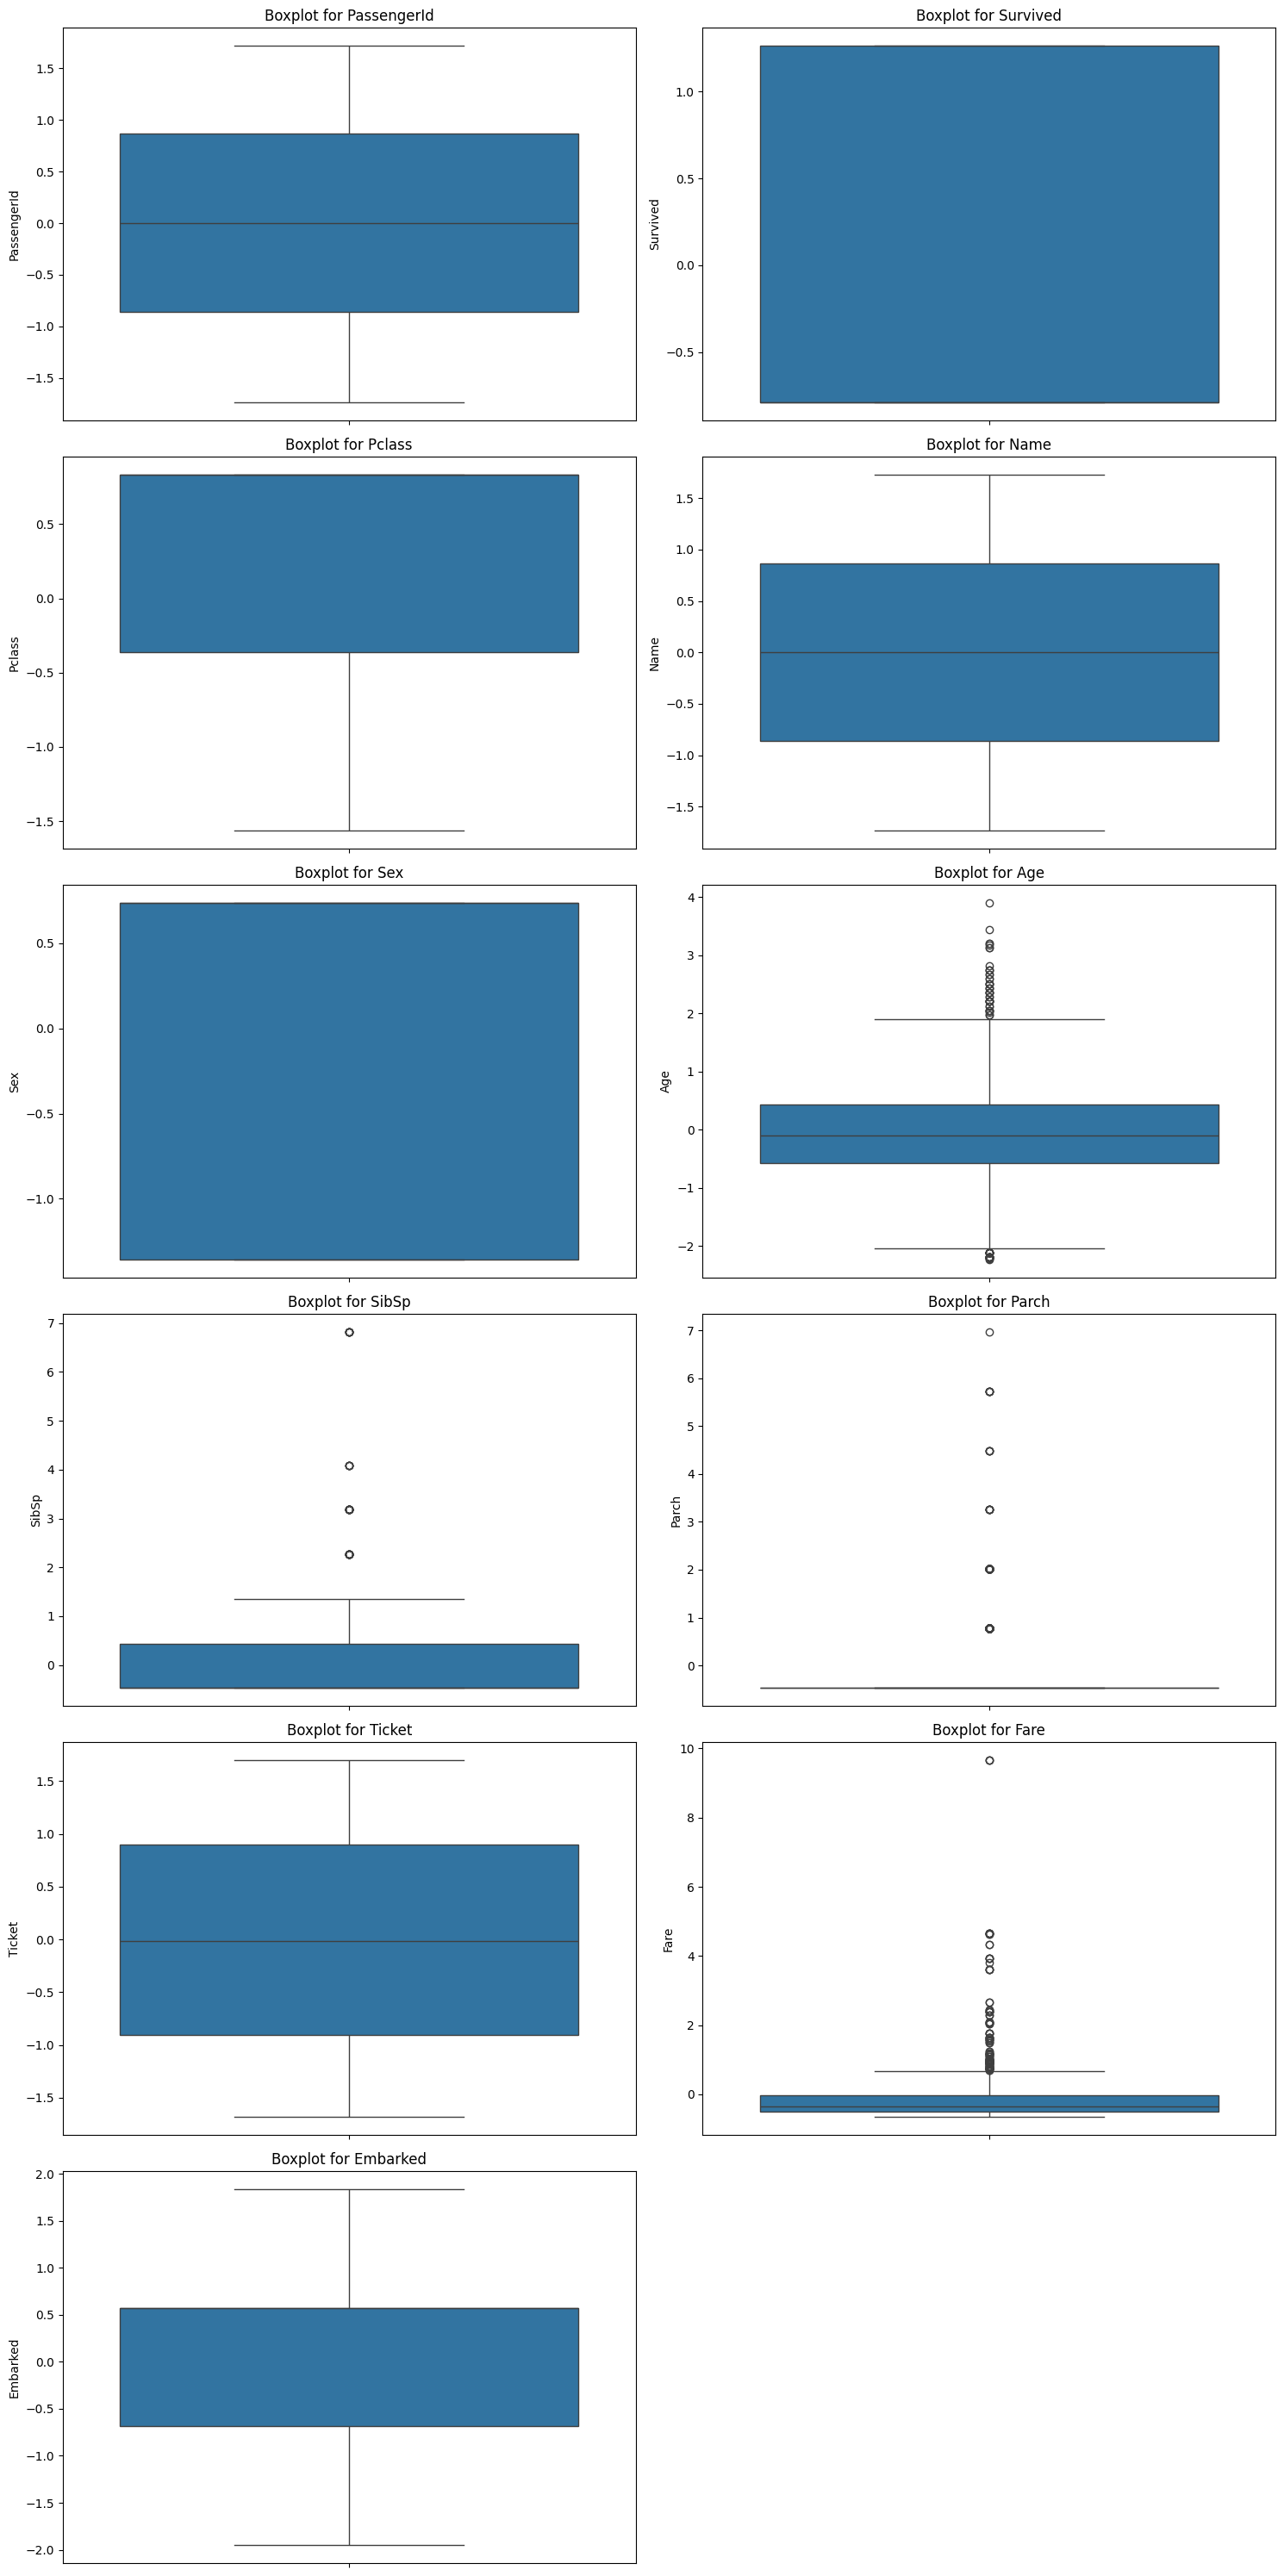

In [ ]:
# شناسایی ستون‌های عددی
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# محاسبه تعداد سطرها و ستون‌ها برای رسم زیرنمودارها
num_columns = 2  # تعداد ستون‌های نمایش
num_rows = (len(numeric_columns) + num_columns - 1) // num_columns  # تعداد سطرها

# رسم نمودار جعبه‌ای برای هر ستون عددی
plt.figure(figsize=(15, 5 * num_rows))

for i, column in enumerate(numeric_columns, 1):
    plt.subplot(num_rows, num_columns, i)  # تنظیمات نمایشی بر اساس تعداد ستون و ردیف
    sns.boxplot(y=df[column])
    plt.title(f'Boxplot for {column}')

plt.tight_layout()
plt.show()

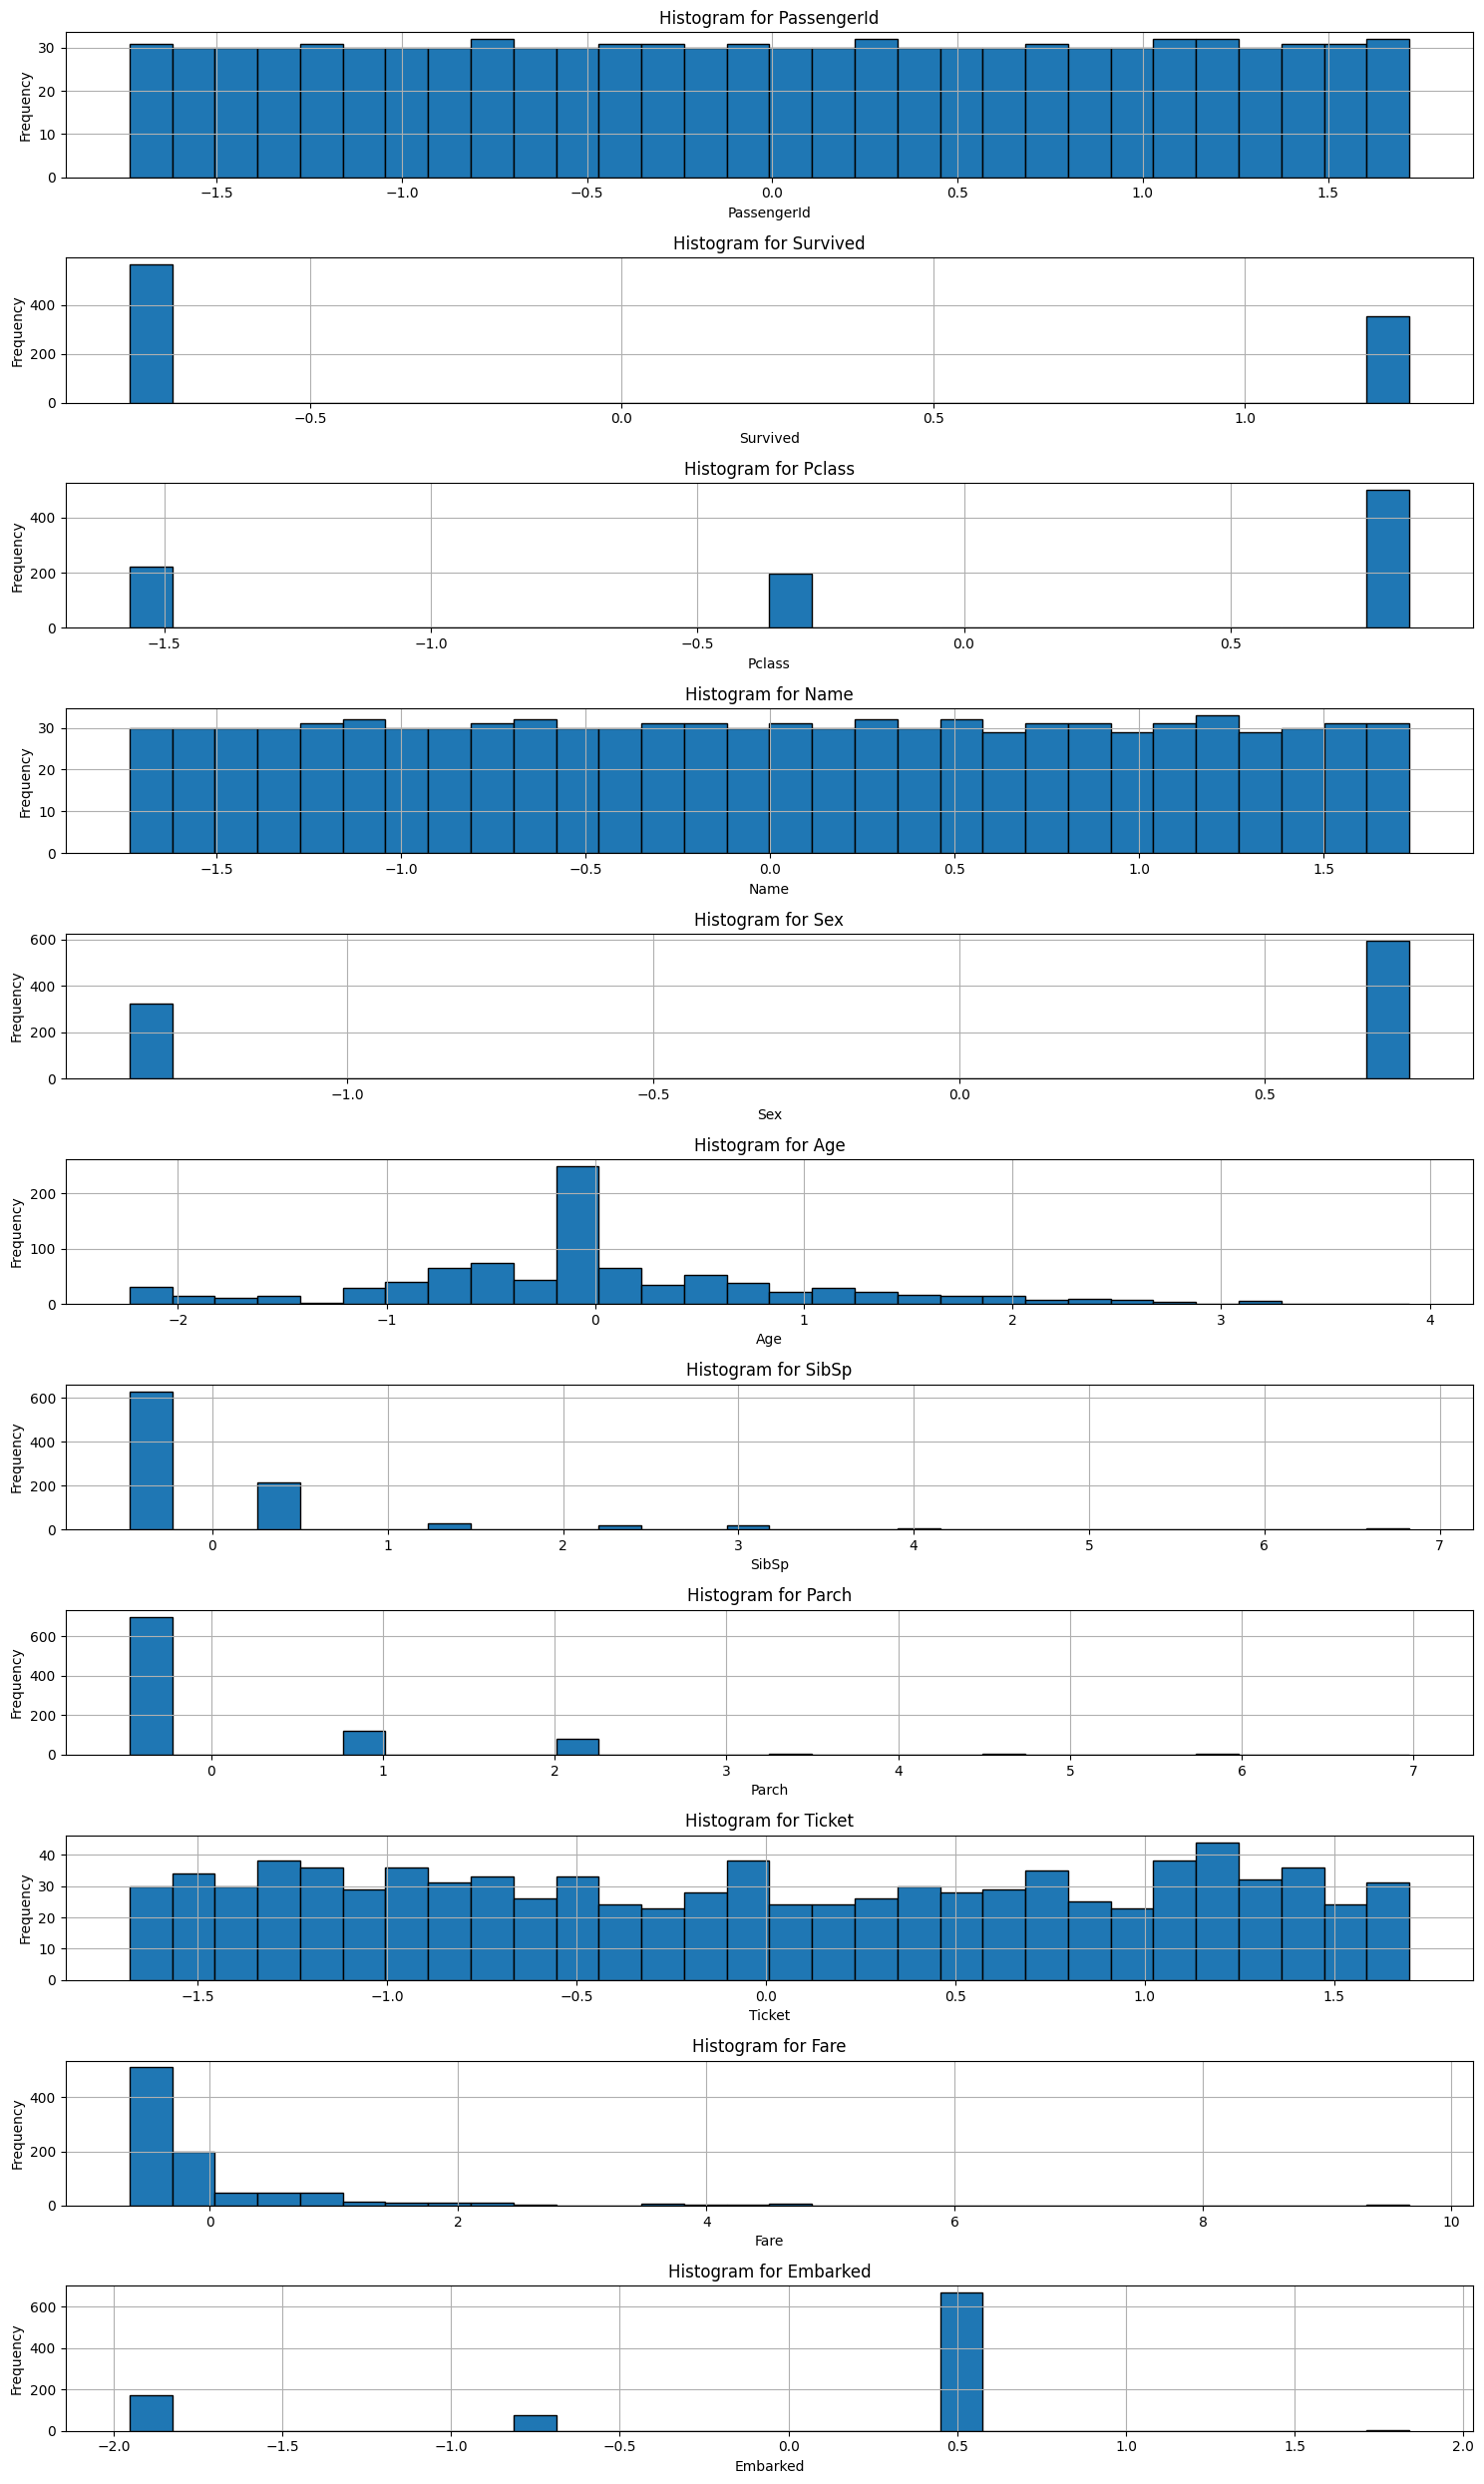

In [ ]:
# شناسایی ستون‌های عددی
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# ایجاد شکل برای رسم هیستوگرام
plt.figure(figsize=(15, 25))

# رسم هیستوگرام برای هر ستون عددی
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(len(numeric_columns), 1, i)  # تنظیم سطرها برای تعداد ستون‌های عددی
    df[column].hist(bins=30, edgecolor='black')  # رسم هیستوگرام
    plt.title(f'Histogram for {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()  # تنظیم نمایش بهینه
plt.show()

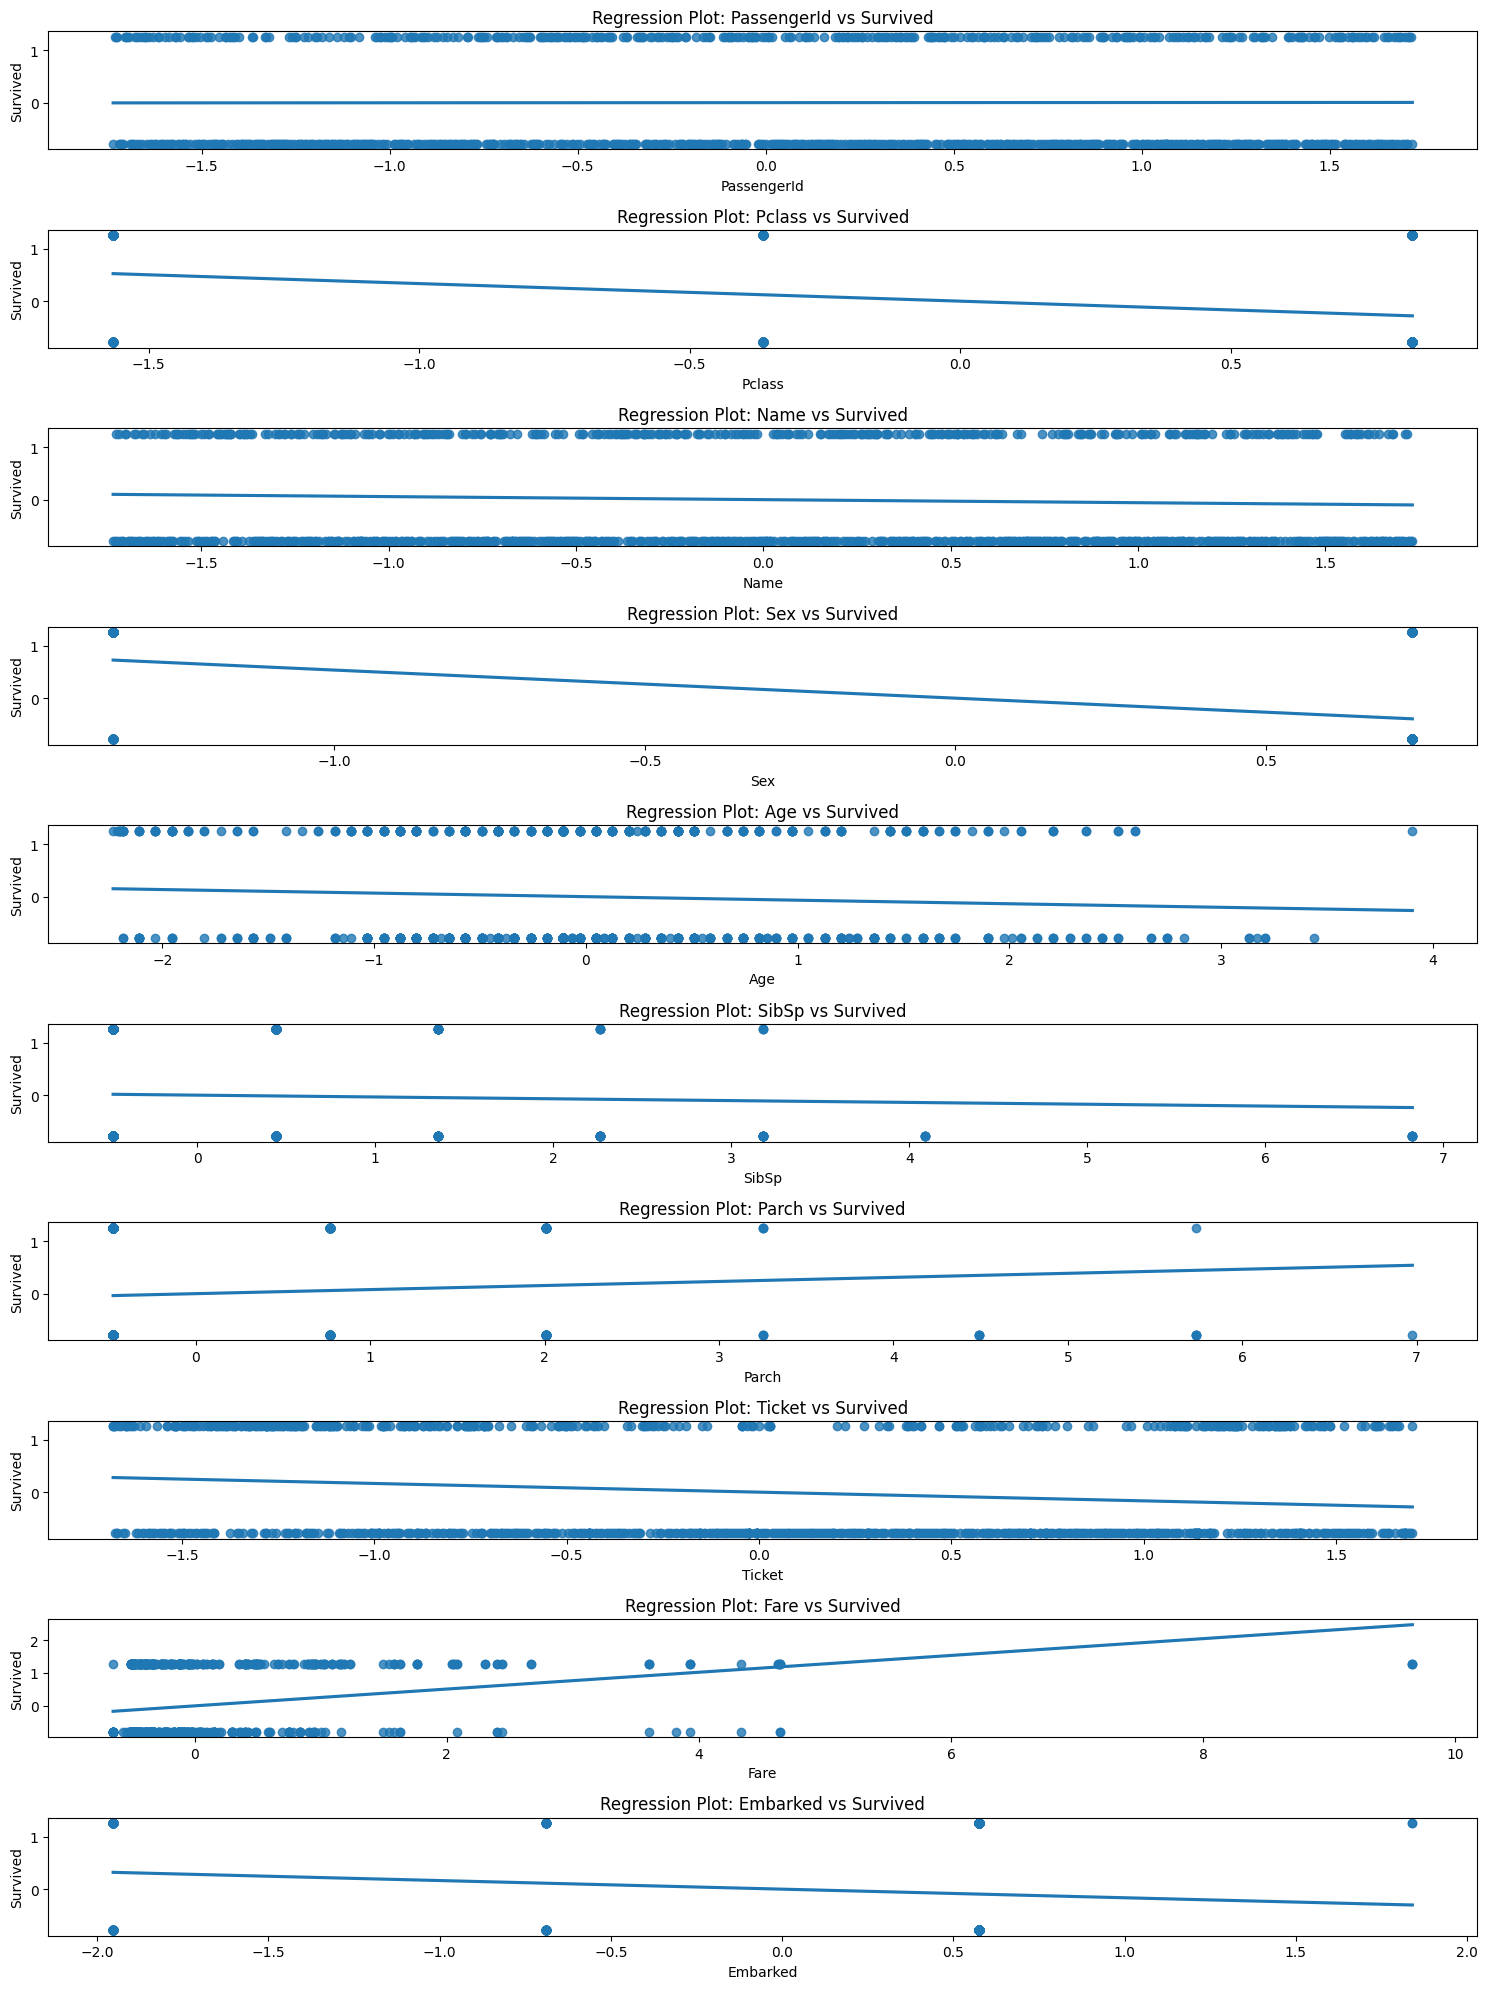

In [ ]:
# شناسایی ستون‌های عددی به جز `Survived`
numeric_columns = df.select_dtypes(include=['float64', 'int64']).drop('Survived', axis=1).columns

# ایجاد شکل برای رسم نمودارهای رگرسیون
plt.figure(figsize=(15, 20))

# رسم نمودارهای رگرسیون
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(len(numeric_columns), 1, i)  # تنظیم سطرها برای تعداد ستون‌های عددی
    sns.regplot(x=df[column], y=df['Survived'], ci=None)  # رسم نمودار رگرسیون
    plt.title(f'Regression Plot: {column} vs Survived')
    plt.xlabel(column)
    plt.ylabel('Survived')

plt.tight_layout()  # تنظیم نمایش بهینه
plt.show()

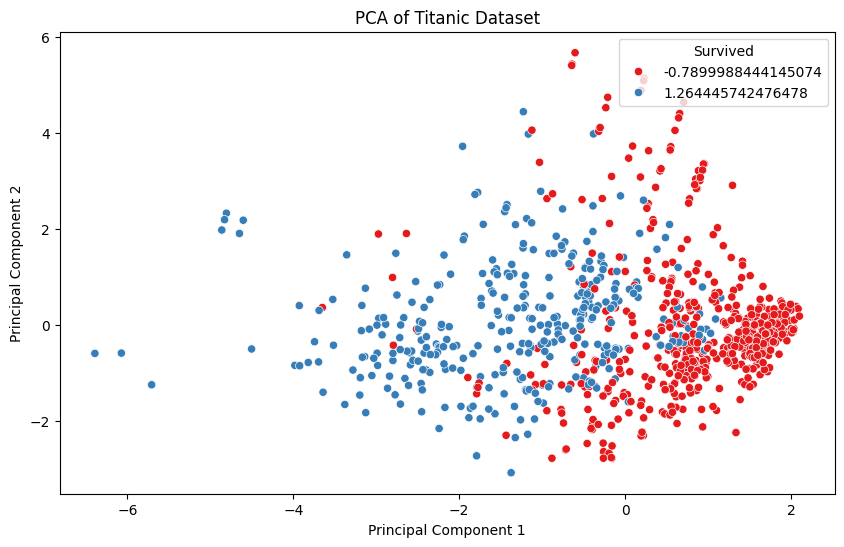

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler  # انتخاب ویژگی‌های عددی
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# حذف مقادیر گم‌شده
df_selected = df[numeric_columns].dropna()

# استانداردسازی داده‌ها
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_selected)

# اجرای PCA
pca = PCA(n_components=2)  # کاهش به دو بعد
X_pca = pca.fit_transform(X_scaled)

# ساخت DataFrame برای نتایج PCA
pca_df = pd.DataFrame(data=X_pca, columns=['PCA1', 'PCA2'])
pca_df['Survived'] = df_selected.loc[df_selected.index, 'Survived'].values

# رسم نتایج PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Survived', data=pca_df, palette='Set1')
plt.title('PCA of Titanic Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Survived', loc='upper right')
plt.show()

In [ ]:
df.to_csv('/content/drive/MyDrive/Colab Notebooks/titanic_h2.csv',index=False)